#  Regression Part 2: Evaluation (Lyna)
**Objective:** Test the regression model and analyze the Dinar prediction errors.

---

--- Regression Results ---
R-Squared Score: 0.7355
Average Error (MAE): 25,293 DZD


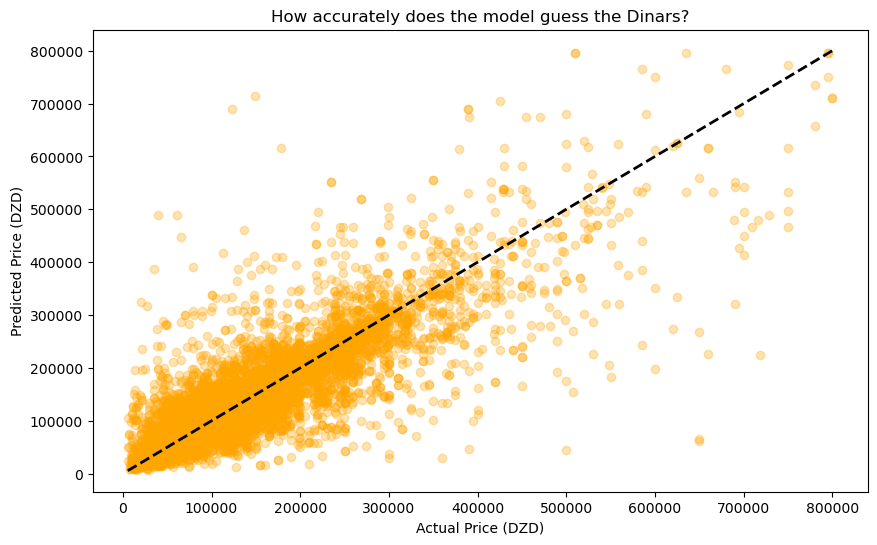

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load Everything
test = pd.read_csv('../../D_RESULTS/testing_dataset.csv')
model = joblib.load('../../D_RESULTS/laptop_regression_model.pkl')
encoders = joblib.load('../../D_RESULTS/regression_encoders.pkl')
features = joblib.load('../../D_RESULTS/regression_features.pkl')

X_test = test[features].copy()
y_test = test['PRICE']

# 2. Encoding
for col, le in encoders.items():
    X_test[col] = X_test[col].astype(str).map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

# 3. Predict
y_pred = model.predict(X_test)

# 4. Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Regression Results ---")
print(f"R-Squared Score: {r2:.4f}")
print(f"Average Error (MAE): {mae:,.0f} DZD")

# 5. Prediction Chart
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Price (DZD)')
plt.ylabel('Predicted Price (DZD)')
plt.title('How accurately does the model guess the Dinars?')
plt.show()